## Details:

**Source: A major Taiwanese bank**

**Time period: April 2005 – September 2005**

**Observations: 30,000 credit card clients**

**Variables: 23 features including credit limit, age, education, payment history, bill amounts, etc.**

**Target: Actual default in the next month (October 2005)**

In [1]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [86]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 

{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [87]:
import pandas as pd

In [88]:
# Combine into a single DataFrame
df = pd.concat([X, y], axis=1)

print(df.shape)
print(df.head())

(30000, 24)
       X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...    X15    X16    X17  \
0   20000   2   2   1  24   2   2  -1  -1   -2  ...      0      0      0   
1  120000   2   2   2  26  -1   2   0   0    0  ...   3272   3455   3261   
2   90000   2   2   2  34   0   0   0   0    0  ...  14331  14948  15549   
3   50000   2   2   1  37   0   0   0   0    0  ...  28314  28959  29547   
4   50000   1   2   1  57  -1   0  -1   0    0  ...  20940  19146  19131   

    X18    X19    X20   X21   X22   X23  Y  
0     0    689      0     0     0     0  1  
1     0   1000   1000  1000     0  2000  1  
2  1518   1500   1000  1000  1000  5000  0  
3  2000   2019   1200  1100  1069  1000  0  
4  2000  36681  10000  9000   689   679  0  

[5 rows x 24 columns]


In [89]:
df.info()          # column types and nulls
df.describe()      # summary statistics
df.isnull().sum()  # check missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
 23  Y       300

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

In [90]:
df.Y.count()

np.int64(30000)

In [91]:
df.Y.mean()

np.float64(0.2212)

In [92]:
df.Y.value_counts()

Y
0    23364
1     6636
Name: count, dtype: int64

In [93]:
df['Y'].value_counts()

Y
0    23364
1     6636
Name: count, dtype: int64

In [94]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop('Y', axis=1)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

   Variable        VIF
0        X1   4.037479
1        X2   9.092210
2        X3   6.731119
3        X4   6.265388
4        X5  10.857679
5        X6   1.918276
6        X7   3.211217
7        X8   3.727427
8        X9   4.440120
9       X10   4.985856
10      X11   3.463800
11      X12  20.823400
12      X13  38.214225
13      X14  31.783029
14      X15  29.548135
15      X16  35.986369
16      X17  21.426076
17      X18   1.907500
18      X19   2.384860
19      X20   1.911689
20      X21   1.805048
21      X22   1.854229
22      X23   1.270665


In [95]:
df.columns = [
'LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE',
'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
'DEFAULT'
]

In [96]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [97]:
df['EDUCATION'] = df['EDUCATION'].replace([5,6,0],4)

In [98]:
df['MARRIAGE'] = df['MARRIAGE'].replace(0,3)

In [99]:
df[['SEX','EDUCATION','MARRIAGE']].value_counts()

SEX  EDUCATION  MARRIAGE
2    2          1           4472
     1          2           4176
     2          2           4080
1    2          2           2940
     1          2           2633
     2          1           2370
2    1          1           2032
     3          1           1813
1    1          1           1690
     3          1           1048
2    3          2           1015
1    3          2            894
2    4          1            152
                2            140
     2          3            104
     3          3             99
1    4          2             86
                1             82
     2          3             64
     3          3             48
     1          3             31
2    1          3             23
     4          3              6
1    4          3              2
Name: count, dtype: int64

In [100]:
df['DEFAULT'].value_counts(normalize=True)

DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

**Convert Categorical Variables to Dummies**

In [101]:
df = pd.get_dummies(df, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)

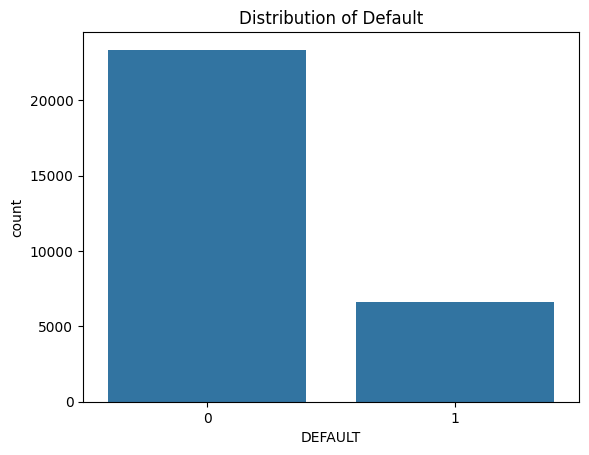

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='DEFAULT', data=df)
plt.title("Distribution of Default")
plt.show()

In [103]:
df.head()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,0,0,0,1,True,True,False,False,False,False
1,120000,26,-1,2,0,0,0,2,2682,1725,...,1000,0,2000,1,True,True,False,False,True,False
2,90000,34,0,0,0,0,0,0,29239,14027,...,1000,1000,5000,0,True,True,False,False,True,False
3,50000,37,0,0,0,0,0,0,46990,48233,...,1100,1069,1000,0,True,True,False,False,False,False
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,9000,689,679,0,False,True,False,False,False,False


In [104]:
df.shape

(30000, 27)

In [105]:
df.columns

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT', 'SEX_2', 'EDUCATION_2',
       'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3'],
      dtype='object')

In [109]:
X = df.drop(columns=['DEFAULT'])

In [110]:
X = X.astype(float)

In [111]:
import statsmodels.api as sm

X = sm.add_constant(X)

In [112]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

       Variable        VIF
0         const  33.959856
1     LIMIT_BAL   1.579845
2           AGE   1.385131
3         PAY_0   1.919991
4         PAY_2   3.175423
5         PAY_3   3.658305
6         PAY_4   4.287850
7         PAY_5   4.725465
8         PAY_6   3.256654
9     BILL_AMT1  14.036195
10    BILL_AMT2  25.866616
11    BILL_AMT3  21.782218
12    BILL_AMT4  20.349079
13    BILL_AMT5  25.005016
14    BILL_AMT6  15.043004
15     PAY_AMT1   1.708412
16     PAY_AMT2   2.237360
17     PAY_AMT3   1.758122
18     PAY_AMT4   1.648807
19     PAY_AMT5   1.688175
20     PAY_AMT6   1.170035
21        SEX_2   1.025608
22  EDUCATION_2   1.367183
23  EDUCATION_3   1.410436
24  EDUCATION_4   1.038240
25   MARRIAGE_2   1.329286
26   MARRIAGE_3   1.023873


**Variance Inflation Factor analysis revealed strong multicollinearity among monthly bill statement variables. To mitigate this issue, the six bill variables were aggregated into a single average bill indicator.**

**Credit utilization ratio.will come later to this**

**Average bill Amount**

In [113]:
df['AVG_BILL'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                     'BILL_AMT4','BILL_AMT5','BILL_AMT6']].mean(axis=1)

In [114]:
df = df.drop(columns=[
'BILL_AMT1','BILL_AMT2','BILL_AMT3',
'BILL_AMT4','BILL_AMT5','BILL_AMT6'
])

In [115]:
X = df.drop(columns=['DEFAULT'])

In [116]:
X = sm.add_constant(X)

In [118]:
X = X.astype(float)

In [119]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

       Variable        VIF
0         const  33.958935
1     LIMIT_BAL   1.573617
2           AGE   1.385078
3         PAY_0   1.919064
4         PAY_2   3.152230
5         PAY_3   3.637357
6         PAY_4   4.275971
7         PAY_5   4.704195
8         PAY_6   3.205212
9      PAY_AMT1   1.216845
10     PAY_AMT2   1.185204
11     PAY_AMT3   1.195769
12     PAY_AMT4   1.147558
13     PAY_AMT5   1.111350
14     PAY_AMT6   1.108975
15        SEX_2   1.024393
16  EDUCATION_2   1.365155
17  EDUCATION_3   1.408877
18  EDUCATION_4   1.034871
19   MARRIAGE_2   1.329015
20   MARRIAGE_3   1.023410
21     AVG_BILL   1.461133


In [124]:
import statsmodels.api as sm

X = df.drop(columns=['DEFAULT'])
X = sm.add_constant(X)
X = X.astype(float)
y = df['DEFAULT']

lpm = sm.OLS(y, X).fit(cov_type='HC3') #robust STD. error
print(lpm.summary())

                            OLS Regression Results                            
Dep. Variable:                DEFAULT   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     150.6
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:23:32   Log-Likelihood:                -14208.
No. Observations:               30000   AIC:                         2.846e+04
Df Residuals:                   29978   BIC:                         2.864e+04
Df Model:                          21                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.2699      0.013     20.087      

In [125]:
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(lpm, power=2, use_f=True)
print(reset_test)

<F test: F=419.7772517540639, p=1.1783522336234768e-92, df_denom=3e+04, df_num=1>


**The Ramsey RESET test strongly rejects the null hypothesis of correct functional form for the Linear Probability Model (p < 0.001). This indicates potential nonlinearity in the relationship between explanatory variables and default probability. Therefore, nonlinear probability models such as the Logit and Probit models are more appropriate for modeling credit default risk.** 

**The Linear Probability Model exhibited heteroskedastic errors and a large condition number due to scale differences among explanatory variables. These limitations are well-known drawbacks of the LPM and further justify the use of nonlinear probability models such as Logit and Probit.**

In [128]:
import statsmodels.api as sm

X = df.drop(columns=['DEFAULT'])
X = sm.add_constant(X)
X = X.astype(float)
y = df['DEFAULT']

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit()

print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.464623
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                DEFAULT   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29978
Method:                           MLE   Df Model:                           21
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                  0.1207
Time:                        14:30:26   Log-Likelihood:                -13939.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.0042      0.086    -11.621      0.000      -1.174      -0.835
LIMIT_BAL   -7.598e-07   1

In [129]:
import numpy as np

odds_ratios = np.exp(logit_result.params)
print(odds_ratios)

const          0.366334
LIMIT_BAL      0.999999
AGE            1.005720
PAY_0          1.789293
PAY_2          1.072215
PAY_3          1.080286
PAY_4          1.026769
PAY_5          1.039397
PAY_6          1.015957
PAY_AMT1       0.999989
PAY_AMT2       0.999992
PAY_AMT3       0.999997
PAY_AMT4       0.999996
PAY_AMT5       0.999997
PAY_AMT6       0.999997
SEX_2          0.898443
EDUCATION_2    0.912332
EDUCATION_3    0.884363
EDUCATION_4    0.303889
MARRIAGE_2     0.828347
MARRIAGE_3     0.817122
AVG_BILL       0.999999
dtype: float64


In [130]:
df['prob_default'] = logit_result.predict(X)

In [131]:
df['predicted_default'] = (df['prob_default'] > 0.5).astype(int)

In [132]:
from sklearn.metrics import confusion_matrix

confusion_matrix(df['DEFAULT'], df['predicted_default'])

array([[22737,   627],
       [ 5066,  1570]])

In [135]:
marginal_effects = logit_result.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:                DEFAULT
Method:                          dydx
At:                           overall
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
LIMIT_BAL   -1.133e-07   2.34e-08     -4.834      0.000   -1.59e-07   -6.74e-08
AGE             0.0009      0.000      3.073      0.002       0.000       0.001
PAY_0           0.0868      0.003     34.652      0.000       0.082       0.092
PAY_2           0.0104      0.003      3.461      0.001       0.005       0.016
PAY_3           0.0115      0.003      3.421      0.001       0.005       0.018
PAY_4           0.0039      0.004      1.058      0.290      -0.003       0.011
PAY_5           0.0058      0.004      1.442      0.149      -0.002       0.014
PAY_6           0.0024      0.003      0.722      0.470      -0.004       0.009
PAY_AMT1    -1.625e-06   3.18e-07     -5.113    

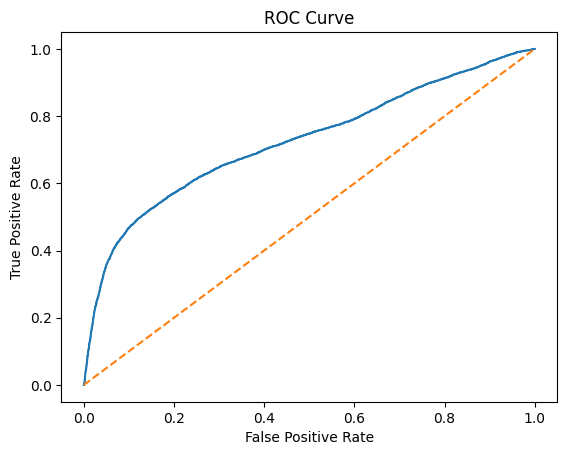

In [136]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y, df['prob_default'])

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [137]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y, df['prob_default'])
print("AUC:", auc)

AUC: 0.7246859339556722


In [138]:
import numpy as np

J = tpr - fpr
ix = np.argmax(J)

best_threshold = thresholds[ix]

print("Best Threshold:", best_threshold)

Best Threshold: 0.26608505160878576


In [139]:
df['predicted_default'] = (df['prob_default'] > best_threshold).astype(int)

In [140]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, df['predicted_default'])
print(cm)

[[19964  3400]
 [ 3180  3456]]


In [141]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y, df['predicted_default'])
recall = recall_score(y, df['predicted_default'])

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.5040840140023337
Recall: 0.5207956600361664


In [142]:
from sklearn.metrics import classification_report

print(classification_report(y, df['predicted_default']))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86     23364
           1       0.50      0.52      0.51      6636

    accuracy                           0.78     30000
   macro avg       0.68      0.69      0.69     30000
weighted avg       0.78      0.78      0.78     30000



In [143]:
from sklearn.metrics import f1_score

f1 = f1_score(y, df['predicted_default'])
print("F1 Score:", f1)

F1 Score: 0.5123035873109991


In [146]:
ks_df = pd.DataFrame({
    'prob': df['prob_default'],
    'actual': df['DEFAULT']
})

ks_df = ks_df.sort_values(by='prob', ascending=False).reset_index(drop=True)

ks_df['cum_default'] = np.cumsum(ks_df['actual']) / ks_df['actual'].sum()
ks_df['cum_non_default'] = np.cumsum(1 - ks_df['actual']) / (1 - ks_df['actual']).sum()
ks_df['ks'] = ks_df['cum_default'] - ks_df['cum_non_default']

ks_stat = ks_df['ks'].max()
ks_idx = ks_df['ks'].idxmax()

print("KS Statistic:", round(ks_stat, 4))

KS Statistic: 0.3754


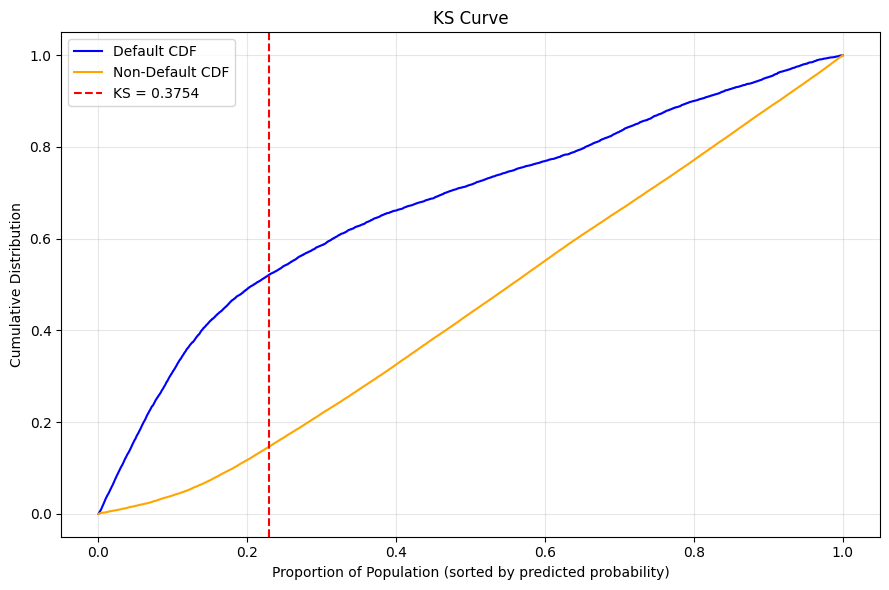

In [150]:
# Use percentile on x-axis
x = np.arange(1, len(ks_df) + 1) / len(ks_df)  

plt.figure(figsize=(9, 6))
plt.plot(x, ks_df['cum_default'], label="Default CDF", color='blue')
plt.plot(x, ks_df['cum_non_default'], label="Non-Default CDF", color='orange')

# Mark the KS statistic point
plt.axvline(x=ks_idx / len(ks_df), color='red', linestyle='--', label=f'KS = {ks_stat:.4f}')

plt.title("KS Curve")
plt.xlabel("Proportion of Population (sorted by predicted probability)")
plt.ylabel("Cumulative Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [155]:
# Sort by predicted probability descending
lift_df = pd.DataFrame({
    'prob': df['prob_default'],
    'actual': df['DEFAULT']
}).sort_values(by='prob', ascending=False).reset_index(drop=True)

# Total default rate in the population (baseline)
baseline = lift_df['actual'].mean()

# Divide into deciles (10 equal buckets)
lift_df['decile'] = pd.qcut(lift_df.index, q=10, labels=False)

# Compute lift per decile
lift_summary = lift_df.groupby('decile').agg(
    total=('actual', 'count'),
    defaults=('actual', 'sum')
).reset_index()

lift_summary['default_rate'] = lift_summary['defaults'] / lift_summary['total']
lift_summary['lift'] = lift_summary['default_rate'] / baseline

# Cumulative lift
lift_summary['cum_defaults'] = lift_summary['defaults'].cumsum()
lift_summary['cum_total'] = lift_summary['total'].cumsum()
lift_summary['cum_default_rate'] = lift_summary['cum_defaults'] / lift_summary['cum_total']
lift_summary['cum_lift'] = lift_summary['cum_default_rate'] / baseline

print(lift_summary[['decile', 'default_rate', 'lift', 'cum_lift']])

   decile  default_rate      lift  cum_lift
0       0      0.687333  3.107294  3.107294
1       1      0.396667  1.793249  2.450271
2       2      0.211667  0.956902  1.952481
3       3      0.167667  0.757987  1.653858
4       4      0.124333  0.562086  1.435503
5       5      0.114667  0.518385  1.282650
6       6      0.141333  0.638939  1.190691
7       7      0.148000  0.669078  1.125490
8       8      0.115000  0.519892  1.058201
9       9      0.105333  0.476190  1.000000


**Plot**

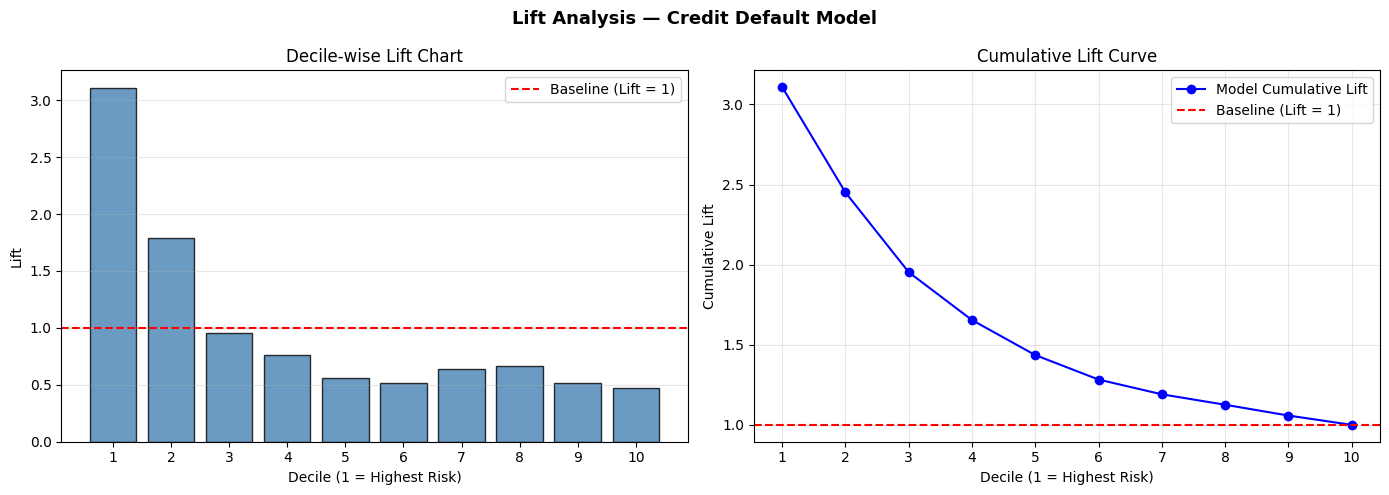

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

deciles = lift_summary['decile'] + 1   # 1 to 10

# Left: Decile-wise Lift
axes[0].bar(deciles, lift_summary['lift'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Baseline (Lift = 1)')
axes[0].set_title('Decile-wise Lift Chart')
axes[0].set_xlabel('Decile (1 = Highest Risk)')
axes[0].set_ylabel('Lift')
axes[0].set_xticks(deciles)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: Cumulative Lift
axes[1].plot(deciles, lift_summary['cum_lift'], marker='o', color='blue', label='Model Cumulative Lift')
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Baseline (Lift = 1)')
axes[1].set_title('Cumulative Lift Curve')
axes[1].set_xlabel('Decile (1 = Highest Risk)')
axes[1].set_ylabel('Cumulative Lift')
axes[1].set_xticks(deciles)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Lift Analysis — Credit Default Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Cumulative Gains Chart**

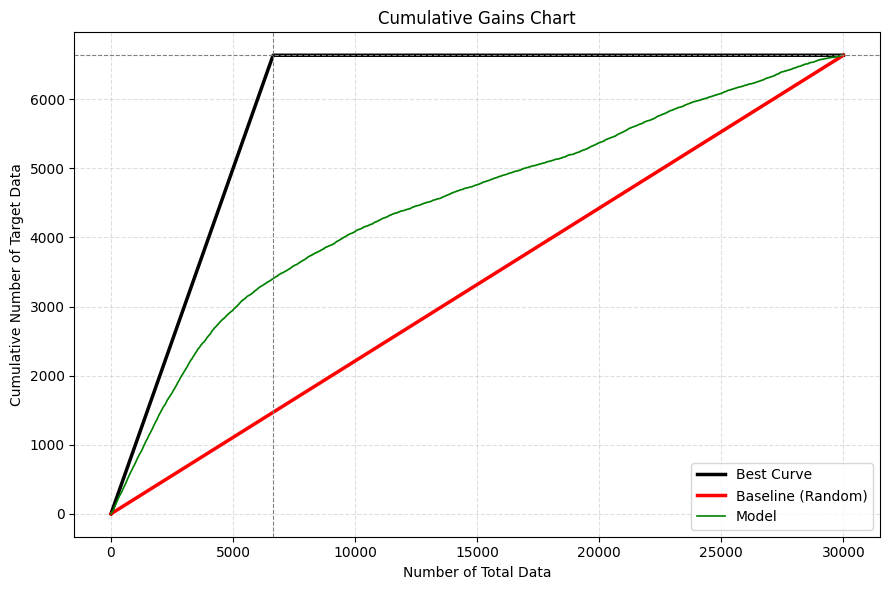

In [161]:
# Setup
gains_df = pd.DataFrame({
    'prob': df['prob_default'],
    'actual': df['DEFAULT']
}).sort_values(by='prob', ascending=False).reset_index(drop=True)

total_obs = len(gains_df)
total_defaults = gains_df['actual'].sum()

# Model curve: cumulative defaults as we go down ranked list
model_cum_defaults = np.cumsum(gains_df['actual'])

# X axis: total number of observations contacted
x = np.arange(1, total_obs + 1)

# Baseline: random selection (straight diagonal line)
baseline = (x / total_obs) * total_defaults

# Best curve: perfect model — capture all defaults first, then flatten
best = np.minimum(x, total_defaults)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))

plt.plot(x, best, color='black', linewidth=2.5, linestyle='-', label='Best Curve')
plt.plot(x, baseline, color='red', linewidth=2.5, linestyle='-', label='Baseline (Random)')
plt.plot(x, model_cum_defaults, color='green', linewidth=1.2, linestyle='-', label='Model')

# Reference lines at total_defaults (horizontal) and where best curve bends (vertical)
plt.axhline(y=total_defaults, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(x=total_defaults, color='gray', linestyle='--', linewidth=0.8)

plt.title('Cumulative Gains Chart')
plt.xlabel('Number of Total Data')
plt.ylabel('Cumulative Number of Target Data')
plt.legend(loc='lower right')
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [159]:
# Gini coefficient from gains chart
from sklearn.metrics import roc_auc_score
gini = 2 * roc_auc_score(df['DEFAULT'], df['prob_default']) - 1
print(f"Gini Coefficient: {gini:.4f}")

Gini Coefficient: 0.4494


In [ ]:
import numpy as np
area_model_baseline = np.trapezoid(model_cum_defaults - baseline, x)
area_best_baseline  = np.trapezoid(best - baseline, x)

area_ratio = area_model_baseline / area_best_baseline

print(f"Area (Model - Baseline):    {area_model_baseline:,.2f}")
print(f"Area (Best  - Baseline):    {area_best_baseline:,.2f}")
print(f"Area Ratio (Gini):          {area_ratio:.4f}")

**Scorecard Transformation (Logit → Credit Score)**

In [166]:
PDO = 20
base_score = 600
base_odds = 50

B = PDO / np.log(2)
A = base_score + B * np.log(base_odds)

In [167]:
df['odds'] = df['prob_default'] / (1 - df['prob_default'])

df['credit_score'] = A - B * np.log(df['odds'])

In [171]:
df['score_bin'] = pd.qcut(df['credit_score'], 10)
score_analysis = df.groupby('score_bin').agg(
    total=('DEFAULT','count'),
    defaults=('DEFAULT','sum')
)

score_analysis['default_rate'] = score_analysis['defaults'] / score_analysis['total']

print(score_analysis)

                     total  defaults  default_rate
score_bin                                         
(566.232, 718.149]    3000      2062      0.687333
(718.149, 739.846]    3000      1190      0.396667
(739.846, 746.005]    3000       635      0.211667
(746.005, 749.804]    3000       503      0.167667
(749.804, 753.567]    3000       373      0.124333
(753.567, 758.777]    3000       344      0.114667
(758.777, 766.94]     3000       424      0.141333
(766.94, 775.024]     3000       444      0.148000
(775.024, 791.706]    3000       345      0.115000
(791.706, 1493.837]   3000       316      0.105333


C:\Users\JAYPAL SINGH\AppData\Local\Temp\ipykernel_21488\2689869303.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_analysis = df.groupby('score_bin').agg(


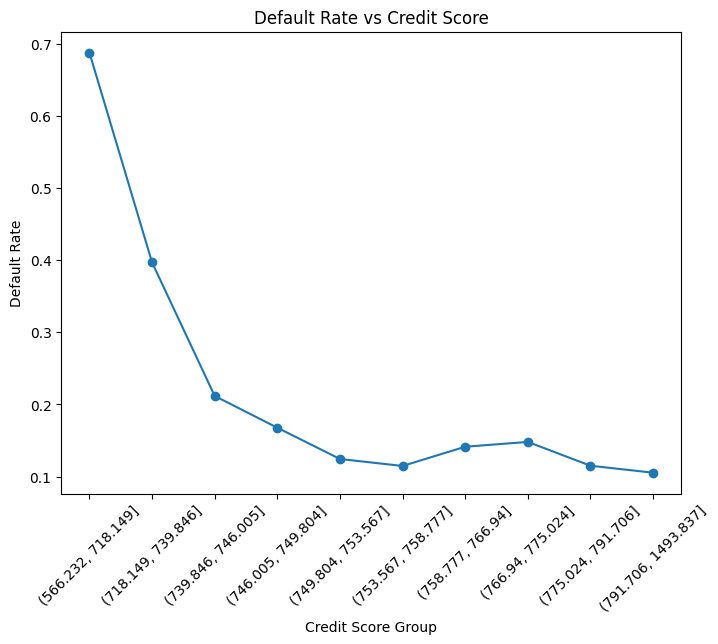

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(score_analysis.index.astype(str), score_analysis['default_rate'], marker='o')

plt.xticks(rotation=45)
plt.xlabel("Credit Score Group")
plt.ylabel("Default Rate")
plt.title("Default Rate vs Credit Score")

plt.show()

**Calibration Plot**

In [173]:
from sklearn.calibration import calibration_curve

# ── Calibration Curve ─────────────────────────────────────────────────────────
fraction_of_positives, mean_predicted_prob = calibration_curve(
    df['DEFAULT'], 
    df['prob_default'], 
    n_bins=10,
    strategy='uniform'   # equal-width bins
)

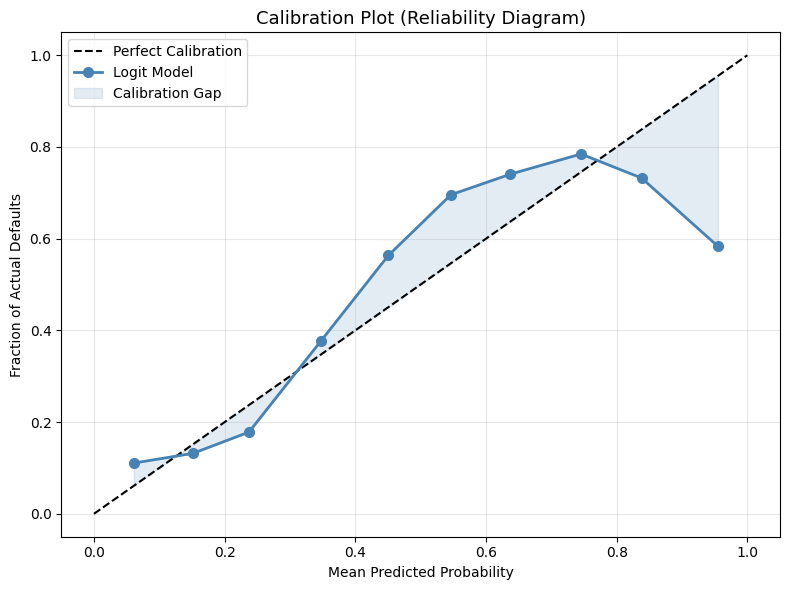

In [174]:
plt.figure(figsize=(8, 6))

# Perfect calibration line
plt.plot([0, 1], [0, 1], 
         color='black', linestyle='--', linewidth=1.5, label='Perfect Calibration')

# Model calibration curve
plt.plot(mean_predicted_prob, fraction_of_positives, 
         marker='o', color='steelblue', linewidth=2, markersize=7, label='Logit Model')

# Fill between model and perfect line to visualize miscalibration
plt.fill_between(mean_predicted_prob, fraction_of_positives, mean_predicted_prob,
                 alpha=0.15, color='steelblue', label='Calibration Gap')

plt.title('Calibration Plot (Reliability Diagram)', fontsize=13)
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Actual Defaults')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [175]:
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(df['DEFAULT'], df['prob_default'])
print(f"Brier Score: {brier:.4f}  (lower is better, 0 = perfect)")

Brier Score: 0.1447  (lower is better, 0 = perfect)


## Probit ##

In [176]:
probit_model = sm.Probit(y, X)
probit_result = probit_model.fit()

print(probit_result.summary())

Optimization terminated successfully.
         Current function value: 0.467964
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:                DEFAULT   No. Observations:                30000
Model:                         Probit   Df Residuals:                    29978
Method:                           MLE   Df Model:                           21
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                  0.1144
Time:                        15:59:09   Log-Likelihood:                -14039.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.6192      0.049    -12.590      0.000      -0.716      -0.523
LIMIT_BAL   -4.095e-07   8

In [177]:
probit_marginal = probit_result.get_margeff(at='overall')
print(probit_marginal.summary())

       Probit Marginal Effects       
Dep. Variable:                DEFAULT
Method:                          dydx
At:                           overall
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
LIMIT_BAL   -1.084e-07    2.3e-08     -4.713      0.000   -1.54e-07   -6.33e-08
AGE             0.0009      0.000      3.294      0.001       0.000       0.001
PAY_0           0.0827      0.003     32.732      0.000       0.078       0.088
PAY_2           0.0116      0.003      3.768      0.000       0.006       0.018
PAY_3           0.0109      0.003      3.223      0.001       0.004       0.018
PAY_4           0.0032      0.004      0.859      0.390      -0.004       0.011
PAY_5           0.0060      0.004      1.474      0.140      -0.002       0.014
PAY_6           0.0018      0.003      0.552      0.581      -0.005       0.008
PAY_AMT1     -1.32e-06   2.41e-07     -5.466    

In [178]:
df['prob_probit'] = probit_result.predict(X)

In [179]:
from sklearn.metrics import roc_auc_score

auc_probit = roc_auc_score(y, df['prob_probit'])
print("Probit AUC:", auc_probit)

Probit AUC: 0.7239142666693085


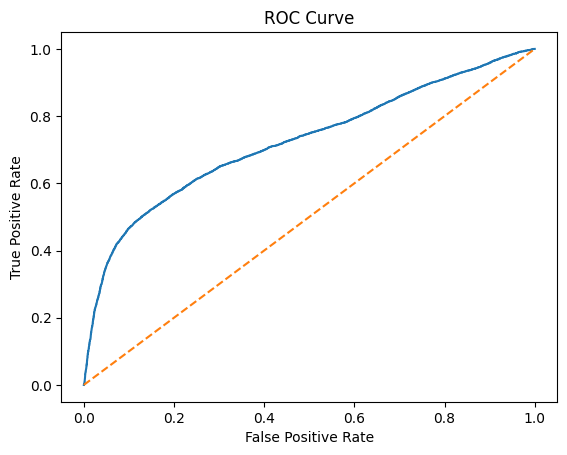

In [180]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y, df['prob_probit'])

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [182]:
import numpy as np

J = tpr - fpr
ix = np.argmax(J)

best_threshold_p = thresholds[ix]

print("Best Threshold:", best_threshold_p)

Best Threshold: 0.269595078828183


In [183]:
df['predicted_probit'] = (df['prob_probit'] > best_threshold_p).astype(int)

In [184]:
from sklearn.metrics import classification_report

print(classification_report(y, df['predicted_probit']))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86     23364
           1       0.50      0.52      0.51      6636

    accuracy                           0.78     30000
   macro avg       0.68      0.69      0.68     30000
weighted avg       0.78      0.78      0.78     30000



In [185]:
ks_df = pd.DataFrame({
    'prob': df['prob_probit'],
    'actual': df['DEFAULT']
})

ks_df = ks_df.sort_values(by='prob', ascending=False).reset_index(drop=True)

ks_df['cum_default'] = np.cumsum(ks_df['actual']) / ks_df['actual'].sum()
ks_df['cum_non_default'] = np.cumsum(1 - ks_df['actual']) / (1 - ks_df['actual']).sum()
ks_df['ks'] = ks_df['cum_default'] - ks_df['cum_non_default']

ks_stat = ks_df['ks'].max()
ks_idx = ks_df['ks'].idxmax()

print("KS Statistic:", round(ks_stat, 4))

KS Statistic: 0.3732


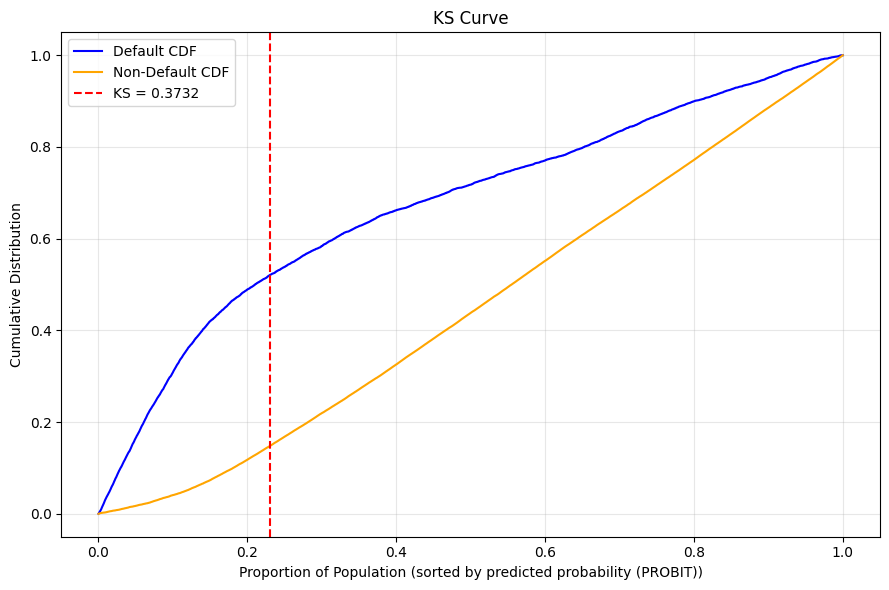

In [186]:
# Use percentile on x-axis
x = np.arange(1, len(ks_df) + 1) / len(ks_df)  

plt.figure(figsize=(9, 6))
plt.plot(x, ks_df['cum_default'], label="Default CDF", color='blue')
plt.plot(x, ks_df['cum_non_default'], label="Non-Default CDF", color='orange')

# Mark the KS statistic point
plt.axvline(x=ks_idx / len(ks_df), color='red', linestyle='--', label=f'KS = {ks_stat:.4f}')

plt.title("KS Curve")
plt.xlabel("Proportion of Population (sorted by predicted probability (PROBIT))")
plt.ylabel("Cumulative Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [187]:
# Sort by predicted probability descending
lift_df = pd.DataFrame({
    'prob': df['prob_probit'],
    'actual': df['DEFAULT']
}).sort_values(by='prob', ascending=False).reset_index(drop=True)

# Total default rate in the population (baseline)
baseline = lift_df['actual'].mean()

# Divide into deciles (10 equal buckets)
lift_df['decile'] = pd.qcut(lift_df.index, q=10, labels=False)

# Compute lift per decile
lift_summary = lift_df.groupby('decile').agg(
    total=('actual', 'count'),
    defaults=('actual', 'sum')
).reset_index()

lift_summary['default_rate'] = lift_summary['defaults'] / lift_summary['total']
lift_summary['lift'] = lift_summary['default_rate'] / baseline

# Cumulative lift
lift_summary['cum_defaults'] = lift_summary['defaults'].cumsum()
lift_summary['cum_total'] = lift_summary['total'].cumsum()
lift_summary['cum_default_rate'] = lift_summary['cum_defaults'] / lift_summary['cum_total']
lift_summary['cum_lift'] = lift_summary['cum_default_rate'] / baseline

print(lift_summary[['decile', 'default_rate', 'lift', 'cum_lift']])

   decile  default_rate      lift  cum_lift
0       0      0.682333  3.084690  3.084690
1       1      0.399333  1.805304  2.444997
2       2      0.209667  0.947860  1.945951
3       3      0.173333  0.783605  1.655365
4       4      0.123000  0.556058  1.435503
5       5      0.117000  0.528933  1.284408
6       6      0.140000  0.632911  1.191337
7       7      0.145333  0.657022  1.124548
8       8      0.113667  0.513864  1.056694
9       9      0.108333  0.489753  1.000000


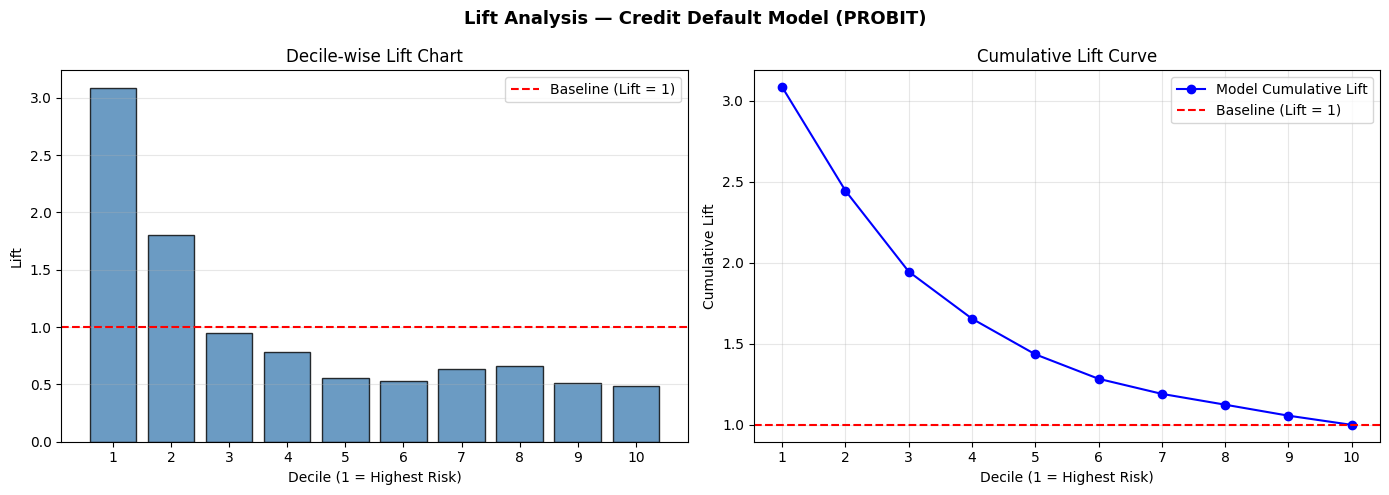

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

deciles = lift_summary['decile'] + 1   # 1 to 10

# Left: Decile-wise Lift
axes[0].bar(deciles, lift_summary['lift'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Baseline (Lift = 1)')
axes[0].set_title('Decile-wise Lift Chart')
axes[0].set_xlabel('Decile (1 = Highest Risk)')
axes[0].set_ylabel('Lift')
axes[0].set_xticks(deciles)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right: Cumulative Lift
axes[1].plot(deciles, lift_summary['cum_lift'], marker='o', color='blue', label='Model Cumulative Lift')
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Baseline (Lift = 1)')
axes[1].set_title('Cumulative Lift Curve')
axes[1].set_xlabel('Decile (1 = Highest Risk)')
axes[1].set_ylabel('Cumulative Lift')
axes[1].set_xticks(deciles)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Lift Analysis — Credit Default Model (PROBIT)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

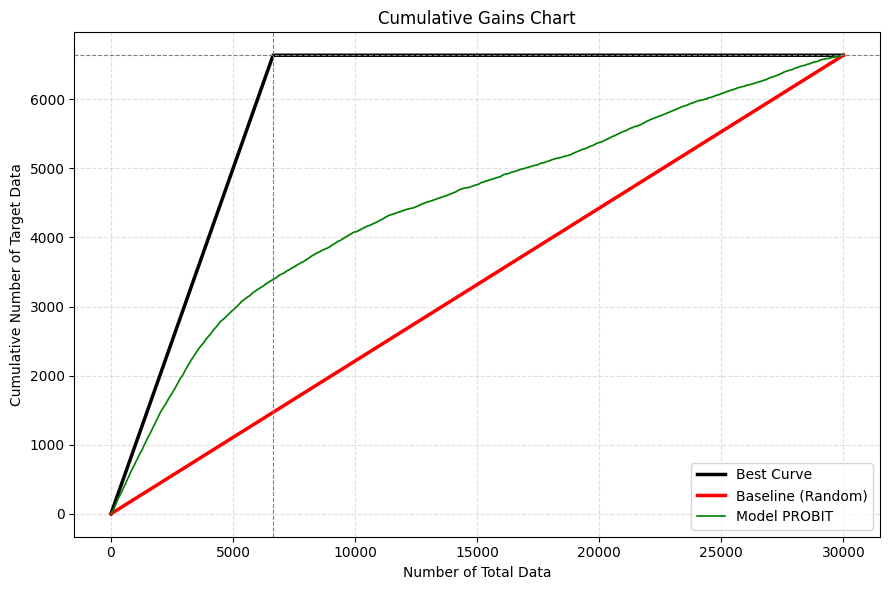

In [189]:
# Setup
gains_df = pd.DataFrame({
    'prob': df['prob_probit'],
    'actual': df['DEFAULT']
}).sort_values(by='prob', ascending=False).reset_index(drop=True)

total_obs = len(gains_df)
total_defaults = gains_df['actual'].sum()

# Model curve: cumulative defaults as we go down ranked list
model_cum_defaults = np.cumsum(gains_df['actual'])

# X axis: total number of observations contacted
x = np.arange(1, total_obs + 1)

# Baseline: random selection (straight diagonal line)
baseline = (x / total_obs) * total_defaults

# Best curve: perfect model — capture all defaults first, then flatten
best = np.minimum(x, total_defaults)

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))

plt.plot(x, best, color='black', linewidth=2.5, linestyle='-', label='Best Curve')
plt.plot(x, baseline, color='red', linewidth=2.5, linestyle='-', label='Baseline (Random)')
plt.plot(x, model_cum_defaults, color='green', linewidth=1.2, linestyle='-', label='Model PROBIT')

# Reference lines at total_defaults (horizontal) and where best curve bends (vertical)
plt.axhline(y=total_defaults, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(x=total_defaults, color='gray', linestyle='--', linewidth=0.8)

plt.title('Cumulative Gains Chart')
plt.xlabel('Number of Total Data')
plt.ylabel('Cumulative Number of Target Data')
plt.legend(loc='lower right')
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [190]:
import numpy as np
area_model_baseline = np.trapezoid(model_cum_defaults - baseline, x)
area_best_baseline  = np.trapezoid(best - baseline, x)

area_ratio = area_model_baseline / area_best_baseline

print(f"Area (Model - Baseline):    {area_model_baseline:,.2f}")
print(f"Area (Best  - Baseline):    {area_best_baseline:,.2f}")
print(f"Area Ratio (Gini):          {area_ratio:.4f}")

Area (Model - Baseline):    34,716,453.61
Area (Best  - Baseline):    77,521,751.61
Area Ratio (Gini):          0.4478


In [191]:
from sklearn.calibration import calibration_curve

# ── Calibration Curve ─────────────────────────────────────────────────────────
fraction_of_positives, mean_predicted_prob = calibration_curve(
    df['DEFAULT'], 
    df['prob_probit'], 
    n_bins=10,
    strategy='uniform'   # equal-width bins
)

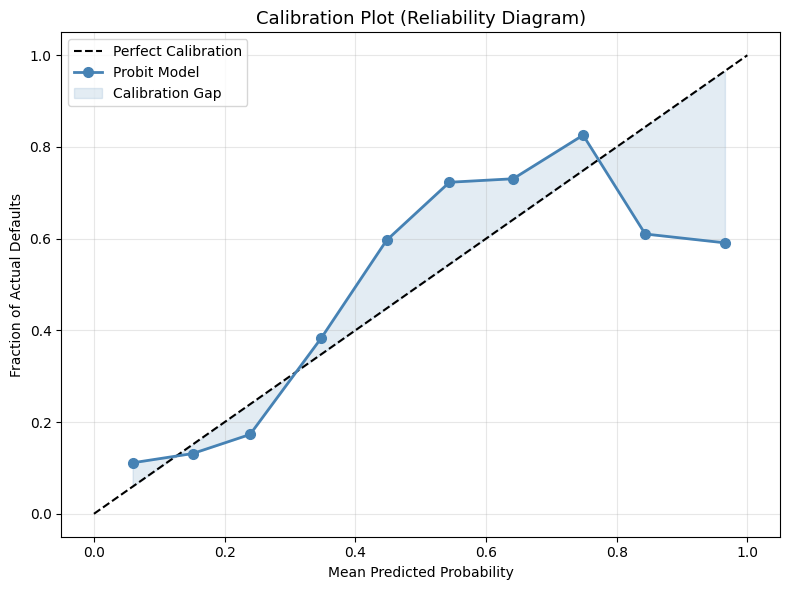

In [192]:
plt.figure(figsize=(8, 6))

# Perfect calibration line
plt.plot([0, 1], [0, 1], 
         color='black', linestyle='--', linewidth=1.5, label='Perfect Calibration')

# Model calibration curve
plt.plot(mean_predicted_prob, fraction_of_positives, 
         marker='o', color='steelblue', linewidth=2, markersize=7, label='Probit Model')

# Fill between model and perfect line to visualize miscalibration
plt.fill_between(mean_predicted_prob, fraction_of_positives, mean_predicted_prob,
                 alpha=0.15, color='steelblue', label='Calibration Gap')

plt.title('Calibration Plot (Reliability Diagram)', fontsize=13)
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Actual Defaults')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [193]:
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(df['DEFAULT'], df['prob_probit'])
print(f"Brier Score: {brier:.4f}  (lower is better, 0 = perfect)")

Brier Score: 0.1461  (lower is better, 0 = perfect)


In [194]:
comparison = {
    "Model": ["Logit", "Probit"],
    "Log-Likelihood": [logit_result.llf, probit_result.llf],
    "AIC": [logit_result.aic, probit_result.aic],
    "BIC": [logit_result.bic, probit_result.bic]
}

import pandas as pd
comparison_table = pd.DataFrame(comparison)

print(comparison_table)

    Model  Log-Likelihood           AIC           BIC
0   Logit   -13938.688133  27921.376265  28104.173224
1  Probit   -14038.907037  28121.814073  28304.611032


**Logit provides a marginally better fit to the data than Probit.**